In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pylfsr as pyl
from pylfsr import LFSR
import math
import pandas as pd

from helper import bytesToPlusMinus, code_acquisition, decode, ber

rng = np.random.default_rng()



# Variance PER SYMBOL
# signal:
# Var(s) = S² with amplitude S
# binary noise:
# Var(n) = N² with amplitude N
# AWGN:  Var(n) = N_0/2 = N² with standard deviation N
# Definition of SNR = E[s²]/E[n²] = S²/N²

# For binary noise/ interferer
# Noise removal at constant N would be trivial, just measure average level and subtract if positive/add if negative
# However in reality, there is a combination of AWGN and interfering signals, as well as changing signal levels

# Todo
# Compare ideal and real results to calculations using double instead of (clipped) int
# Statistically compare bit error rate per SNR and code acquisition performance over large sample size
# Visually they look identical

# Additional calculations:
# T = 1/(2W) <=> 2W = 1/T
# Energy per symbol S²/(2W) for signal, N²/(2W) for noise

repeats = 1
transmitted_bytes = 100
lfsr_size_max = 10
snrs_db = np.array([0, -3, -6, -10, -13, -16, -20, -23, -26, -30, -33, -36, -40])
integration_times = [1,2,4,8,16,32]


S = math.floor(2**13 * (10**(0.05*(-40))))
results = {"awgn" : {}, "bn" : {}, "awgn_ideal" : {}, "bn_ideal" : {}, "code_acq_rate_awgn" : {}}
for i in range(repeats):
    bits = (rng.integers(0,2,transmitted_bytes*8)*2-1)
    data =  (bits*S).astype(np.int64)
    for m in [10]: #range(4,lfsr_size_max+1):
        print("LFSR size: " + str(m))
        fpoly = pyl.get_fpolyList(m=m)[0]
        L = LFSR(fpoly=fpoly)
        code = (L.getFullPeriod() * 2 - 1).astype(np.int64)
        for snr in snrs_db:
            N = S / (10**(0.05 * snr)) #voltage
            res_awgn = []
            res_bn = []
            res_awgn_ideal = []
            res_bn_ideal = []
            code_acq_rate_awgn = [0,0,0,0,0,0]
            for offset in range(0,len(code),1):
                padding = ((rng.integers(0,2,offset)*2-1)*S).astype(np.int64)
                tx_code = code #np.roll(code,offset)
                tx_modulated = np.outer(data, tx_code).flatten()
                tx_sig = np.concat((padding, tx_modulated))

                awgn = rng.normal(size=len(tx_sig), scale=N)
                awgn_int = np.clip(awgn, -2**13, 2**13-1,).round().astype(np.int64)
                binary_noise = ((rng.integers(0,2,len(tx_sig))*2-1)*N).round().astype(np.int64)

                tx_sig_awgn = tx_sig + awgn
                tx_sig_bn = tx_sig + binary_noise
                k = 0
                for t in integration_times:
                    offset_awgn = code_acquisition(tx_sig_awgn, code,t*1023)
                    if offset_awgn == offset: 
                        code_acq_rate_awgn[k] += 1
                    k += 1
                offset_bn = code_acquisition(tx_sig_bn, code)
                #results with estimated offset
                data_awgn = decode(tx_sig_awgn, code, offset_awgn)[:len(data)]
                data_bn = decode(tx_sig_bn, code, offset_bn)[:len(data)]
                ber_awgn = ber(bits, data_awgn)
                ber_bn = ber(bits, data_bn)
                res_awgn.append(ber_awgn)
                res_bn.append(ber_bn)
                #results if code acquisition always is successfull
                data_awgn_ideal = decode(tx_sig_awgn, code, offset)[:len(data)]
                data_bn_ideal = decode(tx_sig_bn, code, offset)[:len(data)]
                ber_awgn_ideal = ber(bits, data_awgn_ideal)
                ber_bn_ideal = ber(bits, data_bn_ideal)
                res_awgn_ideal.append(ber_awgn_ideal)
                res_bn_ideal.append(ber_bn_ideal)
                print("AWGN SNR        : " + str(snr) + "; offset: " + str(offset) + "; detected offset: " + str(offset_awgn) + "; BER: " + str(ber_awgn))
                print("Binary Noise SNR: " + str(snr) + "; offset: " + str(offset) + "; detected offset: " + str(offset_bn) + "; BER: " + str(ber_bn))
            results["awgn"][snr] = res_awgn
            results["code_acq_rate_awgn"][snr] = [code_acq_rate_awgn[k]/len(range(0,len(code),1)) for k in range(len(integration_times))]
            results["bn"][snr] = res_bn
            results["awgn_ideal"][snr] = res_awgn_ideal
            results["bn_ideal"][snr] = res_bn_ideal

LFSR size: 10
AWGN SNR        : 0; offset: 0; detected offset: 0; BER: 0.0
Binary Noise SNR: 0; offset: 0; detected offset: 0; BER: 0.0
AWGN SNR        : 0; offset: 1; detected offset: 1; BER: 0.0
Binary Noise SNR: 0; offset: 1; detected offset: 1; BER: 0.0
AWGN SNR        : 0; offset: 2; detected offset: 2; BER: 0.0
Binary Noise SNR: 0; offset: 2; detected offset: 2; BER: 0.0
AWGN SNR        : 0; offset: 3; detected offset: 3; BER: 0.0
Binary Noise SNR: 0; offset: 3; detected offset: 3; BER: 0.0
AWGN SNR        : 0; offset: 4; detected offset: 4; BER: 0.0
Binary Noise SNR: 0; offset: 4; detected offset: 4; BER: 0.0
AWGN SNR        : 0; offset: 5; detected offset: 5; BER: 0.0
Binary Noise SNR: 0; offset: 5; detected offset: 5; BER: 0.0
AWGN SNR        : 0; offset: 6; detected offset: 6; BER: 0.0
Binary Noise SNR: 0; offset: 6; detected offset: 6; BER: 0.0
AWGN SNR        : 0; offset: 7; detected offset: 7; BER: 0.0
Binary Noise SNR: 0; offset: 7; detected offset: 7; BER: 0.0
AWGN SNR  

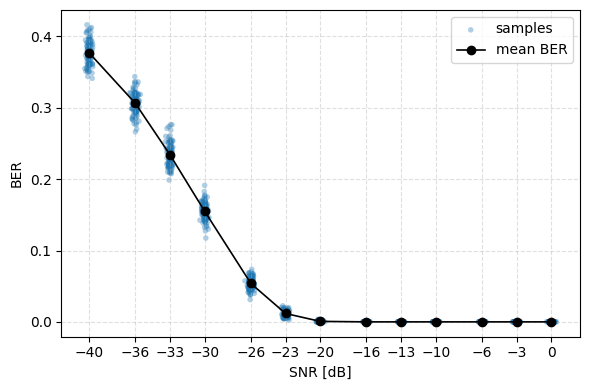

In [4]:
BER_FLOOR = 0
snr_sorted = sorted(results["awgn_ideal"].keys())
 
all_vals = np.concatenate([
    np.clip(results["awgn_ideal"][snr], BER_FLOOR, None) for snr in snr_sorted
])

y_min, y_max = all_vals.min() * 0.7, all_vals.max() * 1.3
 
fig, axs = plt.subplots(1, figsize=(6, 4), sharex=True)
# fig.suptitle("BER vs SNR")
 
panels = [(axs, "awgn_ideal", "AWGN", "tab:blue")]
 
for ax, key, title, color in panels:
    # ax.set_title(title)
    for snr in snr_sorted:
        vals = np.clip(np.asarray(results[key][snr], dtype=float), BER_FLOOR, None)
        jitter = rng.normal(scale=0.15, size=len(vals))
        ax.scatter(snr + jitter, vals, s=16, alpha=0.35, color=color,
                   edgecolors="none", label="samples" if snr == snr_sorted[0] else None)
 
    means = [np.mean(np.clip(results[key][snr], BER_FLOOR, None)) for snr in snr_sorted]
    ax.plot(snr_sorted, means, marker="o", color="black", linewidth=1.2, label="mean BER")

    # r = [results["code_acq_rate_awgn"][snr] for snr in snr_sorted]
    # ax2 = ax.twinx()
    # ax2.set_ylabel("Success Rate")
    # ax2.scatter(snr_sorted, r, marker="^", color="#44AA99", label="Code acquisition rate")
 
    # ax.set_yscale("log")
    # ax.set_ylim(y_min, y_max)
    ax.set_ylabel("BER")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    lines, labels = ax.get_legend_handles_labels()
    # lines2, labels2 = ax2.get_legend_handles_labels()
    # ax.legend(lines + lines2, labels + labels2,loc='center right')
    ax.legend()
 
axs.set_xlabel("SNR [dB]")
axs.set_xticks(snr_sorted)
fig.tight_layout()
plt.savefig("../documentation/images/ber_vs_snr.svg")
plt.show()

 


([<matplotlib.axis.XTick at 0x7fd8be2c4690>,
 [Text(-40, 0, '−40'),
  Text(-36, 0, '−36'),
  Text(-33, 0, '−33'),
  Text(-30, 0, '−30'),
  Text(-26, 0, '−26'),
  Text(-23, 0, '−23'),
  Text(-20, 0, '−20'),
  Text(-16, 0, '−16'),
  Text(-13, 0, '−13'),
  Text(-10, 0, '−10'),
  Text(-6, 0, '−6'),
  Text(-3, 0, '−3'),
  Text(0, 0, '0')])

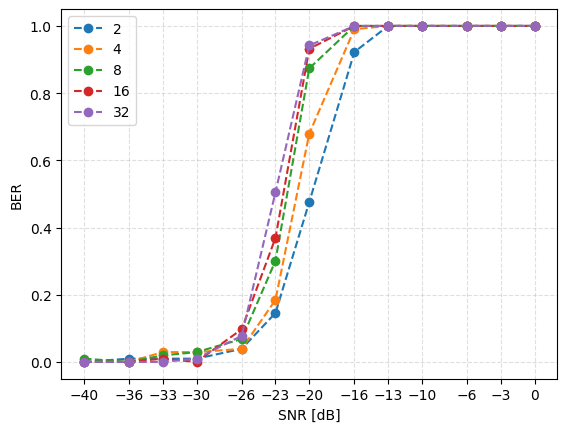

In [ ]:
snr_sorted = sorted(results["code_acq_rate_awgn"].keys())

r = results["code_acq_rate_awgn"]

for k in range(len(integration_times)):
    if (k != 0):
        r = [results["code_acq_rate_awgn"][snr][k] for snr in snr_sorted]
        plt.plot(snr_sorted, r, marker="o", linestyle='dashed', label=integration_times[k])
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.ylabel("BER")
plt.xlabel("SNR [dB]")
plt.xticks(snr_sorted)
plt.savefig("../documentation/images/acq_success_rate.svg")
